# AI-Based Malicious URL Detection
## High-Performance Tabular Classification Pipeline
---
**Target:** `URL_Type_obf_Type` (multi-class: benign, phishing, malware, defacement)  
**Features:** ~80 numerical/engineered features  
**Goal:** Maximize Accuracy | Minimize False Positive Rate (FPR)

## 📦 Dependencies

In [1]:
# Install required libraries (run once)
# !pip install xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# XGBoost
from xgboost import XGBClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Scipy
from scipy.stats import randint, uniform

print("✅ All libraries loaded successfully.")

# Global style
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

✅ All libraries loaded successfully.


---
## STEP 1 — Data Loading & Exploratory Analysis

In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('All.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: (36707, 80)

Column names:
['Querylength', 'domain_token_count', 'path_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld', 'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path', 'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path', 'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength', 'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'argPathRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL', 'ISIpAddressInDomainName', 'CharacterContinuityRate', 'LongestVariableValue', 'URL_DigitCount', 'host_DigitCount', 'Directory_DigitCount', 'File_name_DigitCount', 'Extension_DigitCount', 'Query_DigitCount', 'URL_Letter_Count', 'host_letter_count', 'Directory_LetterCount', 'Filename_LetterCount', 'Extension_LetterCount', 'Query_LetterCount', 'LongestPathTokenLength', 'Domain_LongestWordLength', 'Path_LongestWordL

In [5]:
# ── First look ─────────────────────────────────────────────────────────────────
display(df.head(5))
display(df.dtypes.value_counts().rename('dtype_counts'))

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.400000,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,NaN,-1.0,Defacement
1,0,4,5,5.5,14,6.000000,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.800000,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement
3,0,4,12,5.5,14,5.500000,4,32,16,0,...,0,0,-1,0.640130,0.784493,0.814725,0.663210,0.0,-1.0,Defacement
4,0,4,6,5.5,14,7.333334,4,18,11,0,...,0,0,-1,0.681307,0.784493,0.814725,0.804526,0.0,-1.0,Defacement


int64      58
float64    21
object      1
Name: dtype_counts, dtype: int64

Class Distribution:


,Count,Percentage (%)
URL_Type_obf_Type,,
Defacement,7930,21.60
benign,7781,21.20
phishing,7586,20.67
malware,6712,18.29
spam,6698,18.25


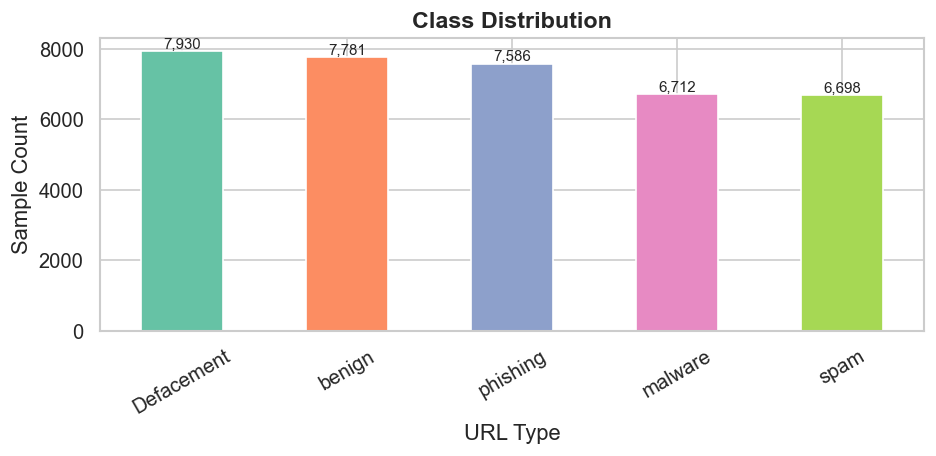

In [6]:
# ── Target column: class distribution ─────────────────────────────────────────
TARGET = 'URL_Type_obf_Type'

class_counts = df[TARGET].value_counts()
class_pct    = df[TARGET].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct.round(2)})
print("Class Distribution:")
display(dist_df)

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(class_counts)))
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('URL Type')
ax.set_ylabel('Sample Count')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(class_counts):
    ax.text(i, v + class_counts.max()*0.01, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

In [7]:
# ── Missing value analysis ─────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)

if len(missing_df) == 0:
    print("✅ No missing values detected.")
else:
    print(f"⚠️  {len(missing_df)} columns have missing values:")
    display(missing_df)

# Basic statistics
print("\nNumerical Summary:")
display(df.describe().T.head(20))

⚠️  9 columns have missing values:


,Missing_Count,Missing_%
NumberRate_Extension,10130,27.60
Entropy_DirectoryName,8468,23.07
avgpathtokenlen,280,0.76
Entropy_Filename,236,0.64
Entropy_Extension,40,0.11
NumberRate_DirectoryName,10,0.03
NumberRate_FileName,10,0.03
Entropy_Afterpath,6,0.02
NumberRate_AfterPath,3,0.01



Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
Querylength,36707.0,21.908110,94.280669,0.0,0.0,0.0,19.0,1385.0
domain_token_count,36707.0,2.857439,0.906562,2.0,2.0,3.0,3.0,19.0
path_token_count,36707.0,8.954668,4.278406,0.0,6.0,8.0,11.0,68.0
avgdomaintokenlen,36707.0,5.401719,1.986858,1.5,4.0,5.0,6.5,29.5
longdomaintokenlen,36707.0,9.746016,4.856580,2.0,6.0,9.0,12.0,63.0
avgpathtokenlen,36427.0,4.556261,2.839388,0.0,3.0,4.1,5.0,105.0
tld,36707.0,2.857439,0.906562,2.0,2.0,3.0,3.0,19.0
charcompvowels,36707.0,14.976517,13.351315,0.0,7.0,13.0,19.0,193.0
charcompace,36707.0,10.216117,10.845807,0.0,5.0,8.0,12.0,142.0
ldl_url,36707.0,3.363909,13.447289,0.0,0.0,0.0,1.0,207.0


---
## STEP 2 — Preprocessing

In [8]:
# ── Handle missing values ──────────────────────────────────────────────────────
# Fill numerical missing values with 0 (safe default for engineered URL features)
df.fillna(0, inplace=True)

# ── Remove any duplicate rows ──────────────────────────────────────────────────
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {n_before - len(df):,} duplicate rows. Remaining: {len(df):,}")

# ── Separate features and target ───────────────────────────────────────────────
X = df.drop(columns=[TARGET])

# Drop any non-numeric columns (e.g. raw URL string if still present)
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"⚠️  Dropping non-numeric columns: {non_numeric}")
    X.drop(columns=non_numeric, inplace=True)

y_raw = df[TARGET]

# ── Encode target labels ────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(y_raw)

print(f"\nLabel Encoding Map:")
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    print(f"  {cls} → {idx}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape : {y.shape}")

Removed 9,754 duplicate rows. Remaining: 26,953

Label Encoding Map:
  Defacement → 0
  benign → 1
  malware → 2
  phishing → 3
  spam → 4

Feature matrix shape: (26953, 79)
Target vector shape : (26953,)


In [18]:
import numpy as np

print("NaN values:", np.isnan(X).sum().sum())
print("Inf values:", np.isinf(X).sum().sum())
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

NaN values: 0
Inf values: 0


---
## STEP 3 — Stratified Train / Test Split

In [21]:
# ── Stratified 80/20 split — preserves class proportions ──────────────────────
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(0.01)
X = selector.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # CRITICAL: ensures each class is proportionally represented
)

print(f"Training set  : {X_train.shape[0]:>7,} rows | {X_train.shape[1]} features")
print(f"Test set      : {X_test.shape[0]:>7,} rows | {X_test.shape[1]} features")

# Verify stratification
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist  = pd.Series(y_test).value_counts(normalize=True).sort_index()

strat_check = pd.DataFrame({
    'Class': le.classes_,
    'Train_%': (train_dist.values * 100).round(2),
    'Test_%' : (test_dist.values  * 100).round(2)
})
print("\nStratification Check:")
display(strat_check)

Training set  :  21,562 rows | 72 features
Test set      :   5,391 rows | 72 features

Stratification Check:


,Class,Train_%,Test_%
0,Defacement,18.80,18.81
1,benign,27.69,27.69
2,malware,6.42,6.42
3,phishing,27.30,27.30
4,spam,19.78,19.77


---
## STEP 4 — Feature Scaling (SVM / Logistic Regression only)

In [22]:
# ── StandardScaler for distance/gradient-based models only ─────────────────────
# Tree-based models (RF, XGBoost) do NOT need scaling — raw X_train / X_test used

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train, transform both
X_test_scaled  = scaler.transform(X_test)

print("✅ StandardScaler fitted on training data.")
print(f"   Mean range  : [{X_train_scaled.mean(axis=0).min():.4f}, {X_train_scaled.mean(axis=0).max():.4f}]")
print(f"   Std  range  : [{X_train_scaled.std(axis=0).min():.4f},  {X_train_scaled.std(axis=0).max():.4f}]")

✅ StandardScaler fitted on training data.
   Mean range  : [-0.0000, 0.0000]
   Std  range  : [1.0000,  1.0000]


---
## 🛠️ Helper: Evaluation Function

In [23]:
# ── Reusable evaluation utility ────────────────────────────────────────────────
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name='Model', classes=None):
    """Train model, evaluate on test set, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='weighted')
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted')

    # ROC-AUC (OvR multi-class)
    try:
        y_proba = model.predict_proba(X_te)
        roc_auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='weighted')
    except Exception:
        roc_auc = np.nan

    # Per-class FPR
    cm   = confusion_matrix(y_te, y_pred)
    fprs = {}
    for i in range(cm.shape[0]):
        fp = cm[:, i].sum() - cm[i, i]   # sum of column i minus TP
        tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        fprs[classes[i] if classes is not None else i] = round(fp / (fp + tn + 1e-9), 4)

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 (w)    : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  FPR/class : {fprs}")
    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=classes, zero_division=0))

    return {
        'model_name': model_name, 'model': model,
        'accuracy': acc, 'f1': f1, 'precision': prec,
        'recall': rec, 'roc_auc': roc_auc,
        'fpr': fprs, 'y_pred': y_pred,
        'mean_fpr': np.mean(list(fprs.values()))
    }

print("✅ evaluate_model() ready.")

✅ evaluate_model() ready.


---
## STEP 5 — Baseline Models

In [24]:
# ── 5.1 Logistic Regression (baseline — uses scaled data) ──────────────────────
lr = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    multi_class='auto',
    random_state=42
)
results = {}
results['Logistic Regression'] = evaluate_model(
    lr, X_train_scaled, X_test_scaled, y_train, y_test,
    model_name='Logistic Regression', classes=le.classes_
)


  Logistic Regression
  Accuracy  : 0.8577
  F1 (w)    : 0.8534
  Precision : 0.8551
  Recall    : 0.8577
  ROC-AUC   : 0.9732
  FPR/class : {'Defacement': np.float64(0.0324), 'benign': np.float64(0.0531), 'malware': np.float64(0.0101), 'phishing': np.float64(0.0663), 'spam': np.float64(0.0247)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.85      0.81      0.83      1014
      benign       0.87      0.94      0.90      1493
     malware       0.75      0.45      0.57       346
    phishing       0.83      0.88      0.85      1472
        spam       0.90      0.90      0.90      1066

    accuracy                           0.86      5391
   macro avg       0.84      0.79      0.81      5391
weighted avg       0.86      0.86      0.85      5391



In [25]:
# ── 5.2 Random Forest (unscaled data) ──────────────────────────────────────────
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
results['Random Forest (base)'] = evaluate_model(
    rf_base, X_train, X_test, y_train, y_test,
    model_name='Random Forest (base)', classes=le.classes_
)


  Random Forest (base)
  Accuracy  : 0.9609
  F1 (w)    : 0.9605
  Precision : 0.9614
  Recall    : 0.9609
  ROC-AUC   : 0.9975
  FPR/class : {'Defacement': np.float64(0.0082), 'benign': np.float64(0.0144), 'malware': np.float64(0.0012), 'phishing': np.float64(0.0265), 'spam': np.float64(0.0021)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.96      0.97      0.97      1014
      benign       0.96      0.99      0.97      1493
     malware       0.98      0.81      0.88       346
    phishing       0.93      0.96      0.94      1472
        spam       0.99      0.97      0.98      1066

    accuracy                           0.96      5391
   macro avg       0.97      0.94      0.95      5391
weighted avg       0.96      0.96      0.96      5391



In [26]:
# ── 5.3 XGBoost (PRIORITY — unscaled data) ─────────────────────────────────────
n_classes = len(np.unique(y))

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=n_classes,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
results['XGBoost (base)'] = evaluate_model(
    xgb_base, X_train, X_test, y_train, y_test,
    model_name='XGBoost (base)', classes=le.classes_
)


  XGBoost (base)
  Accuracy  : 0.9705
  F1 (w)    : 0.9703
  Precision : 0.9706
  Recall    : 0.9705
  ROC-AUC   : 0.9984
  FPR/class : {'Defacement': np.float64(0.0053), 'benign': np.float64(0.0113), 'malware': np.float64(0.0018), 'phishing': np.float64(0.0191), 'spam': np.float64(0.0018)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.98      0.98      0.98      1014
      benign       0.97      0.99      0.98      1493
     malware       0.97      0.85      0.91       346
    phishing       0.95      0.97      0.96      1472
        spam       0.99      0.98      0.99      1066

    accuracy                           0.97      5391
   macro avg       0.97      0.95      0.96      5391
weighted avg       0.97      0.97      0.97      5391



In [29]:
# ── 5.4 SVM (scaled data, fast rbf) ────────────────────────────────────────────
# Note: SVM is slow on large datasets; use a sample if needed
MAX_SVM = 30_000   # cap training rows for SVM speed

if len(X_train_scaled) > MAX_SVM:
    idx = np.random.RandomState(42).choice(len(X_train_scaled), MAX_SVM, replace=False)
    Xs_tr, ys_tr = X_train_scaled[idx], y_train[idx]
    print(f"⚡ SVM: sampled {MAX_SVM:,} rows for speed.")
else:
    Xs_tr, ys_tr = X_train_scaled, y_train

svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
results['SVM (RBF)'] = evaluate_model(
    svm, Xs_tr, X_test_scaled, ys_tr, y_test,
    model_name='SVM (RBF)', classes=le.classes_
)


  SVM (RBF)
  Accuracy  : 0.9369
  F1 (w)    : 0.9359
  Precision : 0.9379
  Recall    : 0.9369
  ROC-AUC   : 0.9933
  FPR/class : {'Defacement': np.float64(0.0164), 'benign': np.float64(0.0226), 'malware': np.float64(0.002), 'phishing': np.float64(0.038), 'spam': np.float64(0.0049)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.93      0.94      0.94      1014
      benign       0.94      0.98      0.96      1493
     malware       0.96      0.70      0.81       346
    phishing       0.90      0.94      0.92      1472
        spam       0.98      0.95      0.96      1066

    accuracy                           0.94      5391
   macro avg       0.94      0.90      0.92      5391
weighted avg       0.94      0.94      0.94      5391



---
## STEP 6 — Hyperparameter Tuning (RandomizedSearchCV)

In [28]:
# ── 6.1 Tune Random Forest ─────────────────────────────────────────────────────
rf_param_dist = {
    'n_estimators'     : randint(100, 600),
    'max_depth'        : [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2', 0.5],
    'bootstrap'        : [True, False]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='roc_auc_ovr_weighted',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(X_train, y_train)

print(f"\n✅ Best RF params : {rf_search.best_params_}")
print(f"   Best CV score  : {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
results['RF (tuned)'] = evaluate_model(
    best_rf, X_train, X_test, y_train, y_test,
    model_name='RF (tuned)', classes=le.classes_
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Best RF params : {'bootstrap': False, 'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 11, 'n_estimators': 575}
   Best CV score  : 0.9966

  RF (tuned)
  Accuracy  : 0.9616
  F1 (w)    : 0.9612
  Precision : 0.9623
  Recall    : 0.9616
  ROC-AUC   : 0.9976
  FPR/class : {'Defacement': np.float64(0.0075), 'benign': np.float64(0.0126), 'malware': np.float64(0.001), 'phishing': np.float64(0.0278), 'spam': np.float64(0.0025)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.97      0.97      0.97      1014
      benign       0.97      0.99      0.98      1493
     malware       0.98      0.80      0.88       346
    phishing       0.93      0.96      0.95      1472
        spam       0.99      0.97      0.98      1066

    accuracy                           0.96      5391
   macro avg       0.97      0.94      0.95      5391
weighted avg   

In [30]:
# ── 6.2 Tune XGBoost ───────────────────────────────────────────────────────────
xgb_param_dist = {
    'n_estimators'     : randint(200, 800),
    'max_depth'        : randint(3, 12),
    'learning_rate'    : uniform(0.01, 0.29),
    'subsample'        : uniform(0.5, 0.5),
    'colsample_bytree' : uniform(0.5, 0.5),
    'min_child_weight' : randint(1, 10),
    'gamma'            : uniform(0, 0.5),
    'reg_alpha'        : uniform(0, 1),
    'reg_lambda'       : uniform(0.5, 2),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softprob',
        num_class=n_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42,
        verbosity=0
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring='roc_auc_ovr_weighted',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_search.fit(X_train, y_train)

print(f"\n✅ Best XGB params: {xgb_search.best_params_}")
print(f"   Best CV score  : {xgb_search.best_score_:.4f}")

best_xgb = xgb_search.best_estimator_
results['XGBoost (tuned)'] = evaluate_model(
    best_xgb, X_train, X_test, y_train, y_test,
    model_name='XGBoost (tuned)', classes=le.classes_
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Best XGB params: {'colsample_bytree': np.float64(0.9010984903770198), 'gamma': np.float64(0.03727532183988541), 'learning_rate': np.float64(0.29619721161415), 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 671, 'reg_alpha': np.float64(0.014079822715084456), 'reg_lambda': np.float64(0.8976848081776103), 'subsample': np.float64(0.855670976374325)}
   Best CV score  : 0.9974

  XGBoost (tuned)
  Accuracy  : 0.9718
  F1 (w)    : 0.9716
  Precision : 0.9719
  Recall    : 0.9718
  ROC-AUC   : 0.9983
  FPR/class : {'Defacement': np.float64(0.005), 'benign': np.float64(0.0092), 'malware': np.float64(0.0024), 'phishing': np.float64(0.0189), 'spam': np.float64(0.0018)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.98      0.98      0.98      1014
      benign       0.98      0.99      0.98      1493
     malware       0.96      0.87      0.91       346
    phishing      

---
## STEP 7 — Class Imbalance Handling

In [31]:
# ── 7.1 Class-weight balanced (built-in) ───────────────────────────────────────
rf_balanced = RandomForestClassifier(
    **{k: v for k, v in rf_search.best_params_.items()},
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
results['RF (balanced weights)'] = evaluate_model(
    rf_balanced, X_train, X_test, y_train, y_test,
    model_name='RF (balanced weights)', classes=le.classes_
)


  RF (balanced weights)
  Accuracy  : 0.9646
  F1 (w)    : 0.9644
  Precision : 0.9648
  Recall    : 0.9646
  ROC-AUC   : 0.9979
  FPR/class : {'Defacement': np.float64(0.008), 'benign': np.float64(0.0105), 'malware': np.float64(0.0024), 'phishing': np.float64(0.0237), 'spam': np.float64(0.0023)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.97      0.97      0.97      1014
      benign       0.97      0.98      0.98      1493
     malware       0.96      0.86      0.91       346
    phishing       0.94      0.96      0.95      1472
        spam       0.99      0.97      0.98      1066

    accuracy                           0.96      5391
   macro avg       0.97      0.95      0.96      5391
weighted avg       0.96      0.96      0.96      5391



In [32]:
# ── 7.2 SMOTE oversampling ─────────────────────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)

# Only apply SMOTE on training set — never on test
try:
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print(f"SMOTE: {len(X_train):,} → {len(X_train_sm):,} training samples")

    smote_dist = pd.Series(y_train_sm).value_counts().sort_index()
    smote_dist.index = le.classes_
    print("Post-SMOTE class distribution:")
    display(smote_dist.rename('Count'))

    # Retrain best XGBoost on SMOTE data
    xgb_smote = XGBClassifier(
        **{k: v for k, v in xgb_search.best_params_.items()},
        objective='multi:softprob',
        num_class=n_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
    results['XGBoost (SMOTE)'] = evaluate_model(
        xgb_smote, X_train_sm, X_test, y_train_sm, y_test,
        model_name='XGBoost (SMOTE)', classes=le.classes_
    )

except Exception as e:
    print(f"⚠️  SMOTE failed (possibly dataset too large or k_neighbors issue): {e}")
    print("Skipping SMOTE — continuing with class_weight approach.")
    X_train_sm, y_train_sm = X_train.copy(), y_train.copy()

SMOTE: 21,562 → 29,855 training samples
Post-SMOTE class distribution:


Defacement    5971
benign        5971
malware       5971
phishing      5971
spam          5971
Name: Count, dtype: int64


  XGBoost (SMOTE)
  Accuracy  : 0.9699
  F1 (w)    : 0.9698
  Precision : 0.9698
  Recall    : 0.9699
  ROC-AUC   : 0.9983
  FPR/class : {'Defacement': np.float64(0.0059), 'benign': np.float64(0.0092), 'malware': np.float64(0.0038), 'phishing': np.float64(0.0176), 'spam': np.float64(0.0028)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.97      0.98      0.98      1014
      benign       0.98      0.98      0.98      1493
     malware       0.94      0.87      0.90       346
    phishing       0.95      0.96      0.96      1472
        spam       0.99      0.98      0.99      1066

    accuracy                           0.97      5391
   macro avg       0.97      0.96      0.96      5391
weighted avg       0.97      0.97      0.97      5391



In [33]:
# ── 7.3 Pick best imbalance strategy by comparing mean FPR ─────────────────────
imb_candidates = ['RF (balanced weights)', 'XGBoost (SMOTE)', 'XGBoost (tuned)']
imb_scores = {k: results[k]['mean_fpr'] for k in imb_candidates if k in results}

best_imb_key = min(imb_scores, key=imb_scores.get)
print(f"\n📊 Imbalance strategy comparison (lower FPR = better):")
for k, v in imb_scores.items():
    marker = ' ← BEST' if k == best_imb_key else ''
    print(f"   {k}: mean FPR = {v:.4f}{marker}")


📊 Imbalance strategy comparison (lower FPR = better):
   RF (balanced weights): mean FPR = 0.0094
   XGBoost (SMOTE): mean FPR = 0.0079
   XGBoost (tuned): mean FPR = 0.0075 ← BEST


---
## STEP 8 — Feature Selection (Importance-based)

In [39]:
original_feature_names = df.drop("URL_Type_obf_Type", axis=1).columns
selected_features = original_feature_names[selector.get_support()]

feat_imp = pd.Series(
    best_xgb.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

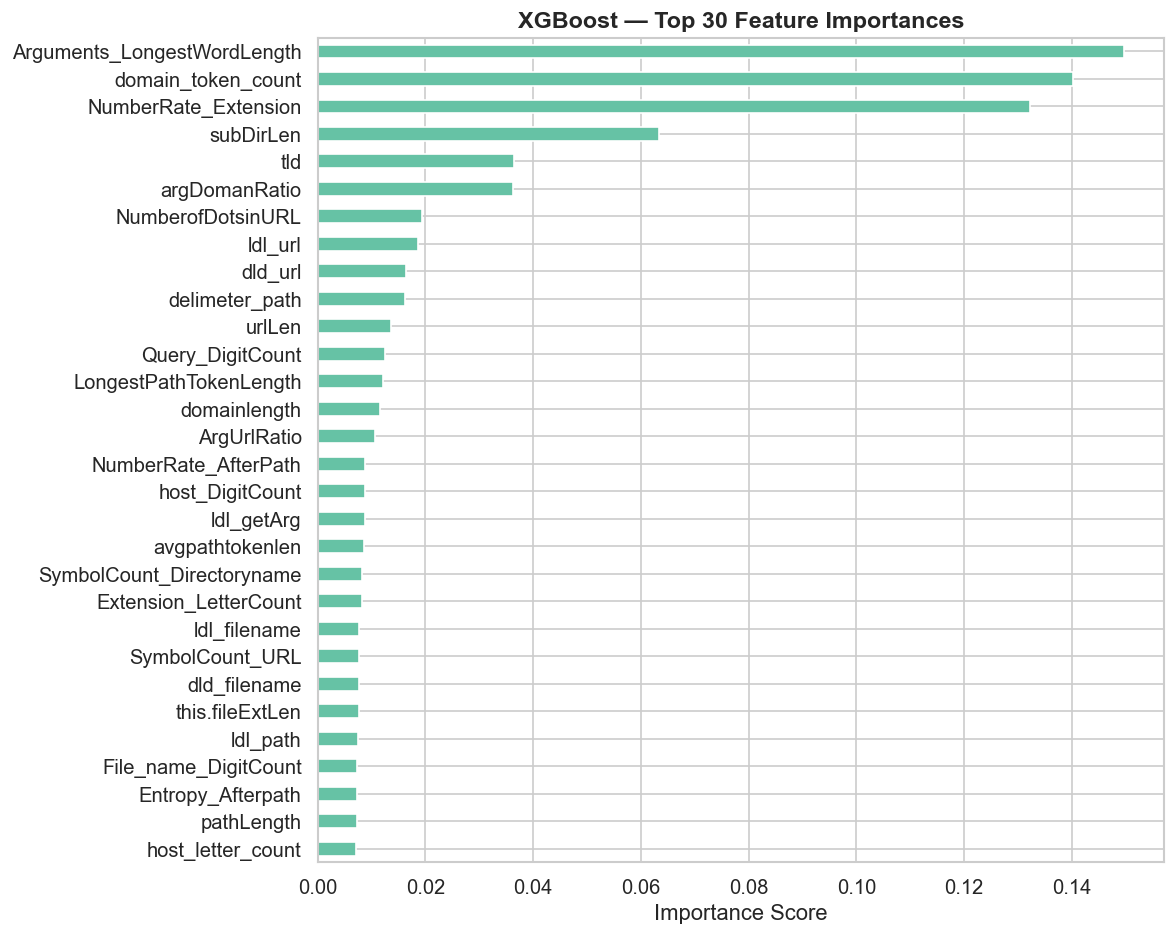


Top 10 features:


Arguments_LongestWordLength    0.149705
domain_token_count             0.140277
NumberRate_Extension           0.132140
subDirLen                      0.063346
tld                            0.036534
argDomanRatio                  0.036295
NumberofDotsinURL              0.019416
ldl_url                        0.018684
dld_url                        0.016436
delimeter_path                 0.016303
Name: Importance, dtype: float32

In [40]:
# Use selected feature names instead of X_train.columns
feat_imp = pd.Series(
    best_xgb.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

# Plot top 30 features
TOP_N = 30
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(TOP_N).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title(f'XGBoost — Top {TOP_N} Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance_xgb.png', bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
display(feat_imp.head(10).rename('Importance'))

In [42]:
feat_to_idx = {name: i for i, name in enumerate(selected_features)}
top_indices = [feat_to_idx[f] for f in top_feats]

r = evaluate_model(
    xgb_fs,
    X_train[:, top_indices],
    X_test[:, top_indices],
    y_train, y_test,
    model_name=f'XGBoost (top-{n_feat} feats)',
    classes=le.classes_
)


  XGBoost (top-20 feats)
  Accuracy  : 0.9390
  F1 (w)    : 0.9386
  Precision : 0.9387
  Recall    : 0.9390
  ROC-AUC   : 0.9947
  FPR/class : {'Defacement': np.float64(0.0137), 'benign': np.float64(0.018), 'malware': np.float64(0.0067), 'phishing': np.float64(0.0339), 'spam': np.float64(0.0074)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.94      0.95      0.95      1014
      benign       0.95      0.98      0.97      1493
     malware       0.89      0.79      0.84       346
    phishing       0.91      0.92      0.91      1472
        spam       0.97      0.95      0.96      1066

    accuracy                           0.94      5391
   macro avg       0.93      0.92      0.92      5391
weighted avg       0.94      0.94      0.94      5391



In [45]:
# Map feature names → indices
feat_to_idx = {name: i for i, name in enumerate(selected_features)}

# ── 8.2 Select top features ────────────────────────────────────────────────────
TOP_FEATURES_LIST = [20, 30, 40]
fs_results = {}

for n_feat in TOP_FEATURES_LIST:
    top_feats = feat_imp.head(n_feat).index.tolist()
    top_indices = [feat_to_idx[f] for f in top_feats]

    xgb_fs = XGBClassifier(
        **{k: v for k, v in xgb_search.best_params_.items()},
        objective='multi:softprob',
        num_class=n_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )

    r = evaluate_model(
        xgb_fs,
        X_train[:, top_indices],
        X_test[:, top_indices],
        y_train, y_test,
        model_name=f'XGBoost (top-{n_feat} feats)',
        classes=le.classes_
    )

    fs_results[n_feat] = r
    results[f'XGBoost (top-{n_feat} feats)'] = r

# Best feature count by ROC-AUC
best_n = max(fs_results, key=lambda k: fs_results[k]['roc_auc'])
print(f"\n✅ Best feature subset: top-{best_n} features (ROC-AUC: {fs_results[best_n]['roc_auc']:.4f})")

# Final selected features
SELECTED_FEATURES = feat_imp.head(best_n).index.tolist()
SELECTED_INDICES = [feat_to_idx[f] for f in SELECTED_FEATURES]

X_train_sel = X_train[:, SELECTED_INDICES]
X_test_sel  = X_test[:, SELECTED_INDICES]

best_xgb_sel = fs_results[best_n]['model']


  XGBoost (top-20 feats)
  Accuracy  : 0.9390
  F1 (w)    : 0.9386
  Precision : 0.9387
  Recall    : 0.9390
  ROC-AUC   : 0.9947
  FPR/class : {'Defacement': np.float64(0.0137), 'benign': np.float64(0.018), 'malware': np.float64(0.0067), 'phishing': np.float64(0.0339), 'spam': np.float64(0.0074)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.94      0.95      0.95      1014
      benign       0.95      0.98      0.97      1493
     malware       0.89      0.79      0.84       346
    phishing       0.91      0.92      0.91      1472
        spam       0.97      0.95      0.96      1066

    accuracy                           0.94      5391
   macro avg       0.93      0.92      0.92      5391
weighted avg       0.94      0.94      0.94      5391


  XGBoost (top-30 feats)
  Accuracy  : 0.9549
  F1 (w)    : 0.9546
  Precision : 0.9548
  Recall    : 0.9549
  ROC-AUC   : 0.9963
  FPR/class : {'Defacement': np.float64(0.0098), 'benign

---
## STEP 9 — Ensemble Models

In [46]:
# ── 9.1 Voting Classifier (soft voting — RF + XGBoost) ────────────────────────

# Rebuild fresh estimators with best params (no fitted state inside VotingClassifier)
rf_for_vote = RandomForestClassifier(
    **{k: v for k, v in rf_search.best_params_.items()},
    n_jobs=-1,
    random_state=42
)
xgb_for_vote = XGBClassifier(
    **{k: v for k, v in xgb_search.best_params_.items()},
    objective='multi:softprob',
    num_class=n_classes,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

voting_clf = VotingClassifier(
    estimators=[
        ('rf',  rf_for_vote),
        ('xgb', xgb_for_vote)
    ],
    voting='soft',   # uses predicted probabilities — generally better
    n_jobs=-1
)

results['Voting (RF+XGB)'] = evaluate_model(
    voting_clf, X_train, X_test, y_train, y_test,
    model_name='Voting (RF + XGBoost)', classes=le.classes_
)


  Voting (RF + XGBoost)
  Accuracy  : 0.9705
  F1 (w)    : 0.9703
  Precision : 0.9707
  Recall    : 0.9705
  ROC-AUC   : 0.9982
  FPR/class : {'Defacement': np.float64(0.0053), 'benign': np.float64(0.01), 'malware': np.float64(0.0016), 'phishing': np.float64(0.0204), 'spam': np.float64(0.0021)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.98      0.98      0.98      1014
      benign       0.97      0.99      0.98      1493
     malware       0.97      0.84      0.90       346
    phishing       0.95      0.97      0.96      1472
        spam       0.99      0.98      0.99      1066

    accuracy                           0.97      5391
   macro avg       0.97      0.95      0.96      5391
weighted avg       0.97      0.97      0.97      5391



In [47]:
# ── 9.2 Stacking Classifier (RF + XGBoost base → LR meta) ─────────────────────
rf_for_stack = RandomForestClassifier(
    **{k: v for k, v in rf_search.best_params_.items()},
    n_jobs=-1,
    random_state=42
)
xgb_for_stack = XGBClassifier(
    **{k: v for k, v in xgb_search.best_params_.items()},
    objective='multi:softprob',
    num_class=n_classes,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
meta_lr = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)

stacking_clf = StackingClassifier(
    estimators=[
        ('rf',  rf_for_stack),
        ('xgb', xgb_for_stack)
    ],
    final_estimator=meta_lr,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False    # only meta-features passed to LR
)

results['Stacking (RF+XGB→LR)'] = evaluate_model(
    stacking_clf, X_train, X_test, y_train, y_test,
    model_name='Stacking (RF+XGB → LR)', classes=le.classes_
)


  Stacking (RF+XGB → LR)
  Accuracy  : 0.9705
  F1 (w)    : 0.9703
  Precision : 0.9706
  Recall    : 0.9705
  ROC-AUC   : 0.9980
  FPR/class : {'Defacement': np.float64(0.0053), 'benign': np.float64(0.0092), 'malware': np.float64(0.0022), 'phishing': np.float64(0.0204), 'spam': np.float64(0.0021)}

Classification Report:
              precision    recall  f1-score   support

  Defacement       0.98      0.98      0.98      1014
      benign       0.98      0.98      0.98      1493
     malware       0.96      0.86      0.91       346
    phishing       0.95      0.97      0.96      1472
        spam       0.99      0.98      0.99      1066

    accuracy                           0.97      5391
   macro avg       0.97      0.95      0.96      5391
weighted avg       0.97      0.97      0.97      5391



---
## STEP 10 — Full Evaluation Summary

In [48]:
# ── Build summary table of all models ─────────────────────────────────────────
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        'Model'      : r['model_name'],
        'Accuracy'   : round(r['accuracy'],  4),
        'F1 (w)'     : round(r['f1'],        4),
        'Precision'  : round(r['precision'], 4),
        'Recall'     : round(r['recall'],    4),
        'ROC-AUC'    : round(r['roc_auc'],   4) if not np.isnan(r['roc_auc']) else 'N/A',
        'Mean FPR'   : round(r['mean_fpr'],  4)
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("\n📊 Model Performance Summary (sorted by Accuracy):")
display(summary_df.style.background_gradient(subset=['Accuracy','F1 (w)','ROC-AUC'], cmap='Greens')
                        .background_gradient(subset=['Mean FPR'], cmap='Reds_r'))


📊 Model Performance Summary (sorted by Accuracy):


,Model,Accuracy,F1 (w),Precision,Recall,ROC-AUC,Mean FPR
0,XGBoost (tuned),0.971800,0.971600,0.971900,0.971800,0.998300,0.007500
1,Stacking (RF+XGB → LR),0.970500,0.970300,0.970600,0.970500,0.998000,0.007800
2,Voting (RF + XGBoost),0.970500,0.970300,0.970700,0.970500,0.998200,0.007900
3,XGBoost (base),0.970500,0.970300,0.970600,0.970500,0.998400,0.007900
4,XGBoost (SMOTE),0.969900,0.969800,0.969800,0.969900,0.998300,0.007900
5,XGBoost (top-40 feats),0.966100,0.965900,0.965900,0.966100,0.997800,0.008900
6,RF (balanced weights),0.964600,0.964400,0.964800,0.964600,0.997900,0.009400
7,RF (tuned),0.961600,0.961200,0.962300,0.961600,0.997600,0.010300
8,Random Forest (base),0.960900,0.960500,0.961400,0.960900,0.997500,0.010500
9,XGBoost (top-30 feats),0.954900,0.954600,0.954800,0.954900,0.996300,0.011800


In [49]:
# ── Identify best model overall ────────────────────────────────────────────────
best_row = summary_df.iloc[0]
print(f"\n🏆 Best Model  : {best_row['Model']}")
print(f"   Accuracy   : {best_row['Accuracy']}")
print(f"   F1 Score   : {best_row['F1 (w)']}")
print(f"   ROC-AUC    : {best_row['ROC-AUC']}")
print(f"   Mean FPR   : {best_row['Mean FPR']}")


🏆 Best Model  : XGBoost (tuned)
   Accuracy   : 0.9718
   F1 Score   : 0.9716
   ROC-AUC    : 0.9983
   Mean FPR   : 0.0075



False Positive Rate per class — XGBoost (tuned):


,URL_Type,FPR
3,phishing,0.0189
1,benign,0.0092
0,Defacement,0.0050
2,malware,0.0024
4,spam,0.0018


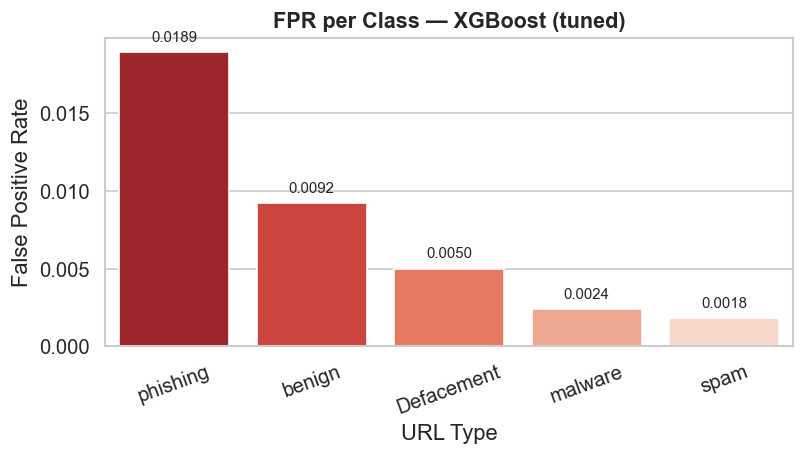

In [50]:
# ── FPR per class — best model ─────────────────────────────────────────────────
best_key = summary_df.iloc[0]['Model']
best_result = next(r for r in results.values() if r['model_name'] == best_key)

fpr_df = pd.DataFrame(
    list(best_result['fpr'].items()),
    columns=['URL_Type', 'FPR']
).sort_values('FPR', ascending=False)

print(f"\nFalse Positive Rate per class — {best_key}:")
display(fpr_df)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=fpr_df, x='URL_Type', y='FPR', palette='Reds_r', ax=ax)
ax.set_title(f'FPR per Class — {best_key}', fontsize=13, fontweight='bold')
ax.set_xlabel('URL Type')
ax.set_ylabel('False Positive Rate')
ax.tick_params(axis='x', rotation=20)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x()+p.get_width()/2, p.get_height()+0.0005),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fpr_per_class.png', bbox_inches='tight')
plt.show()

---
## STEP 11 — Visualizations

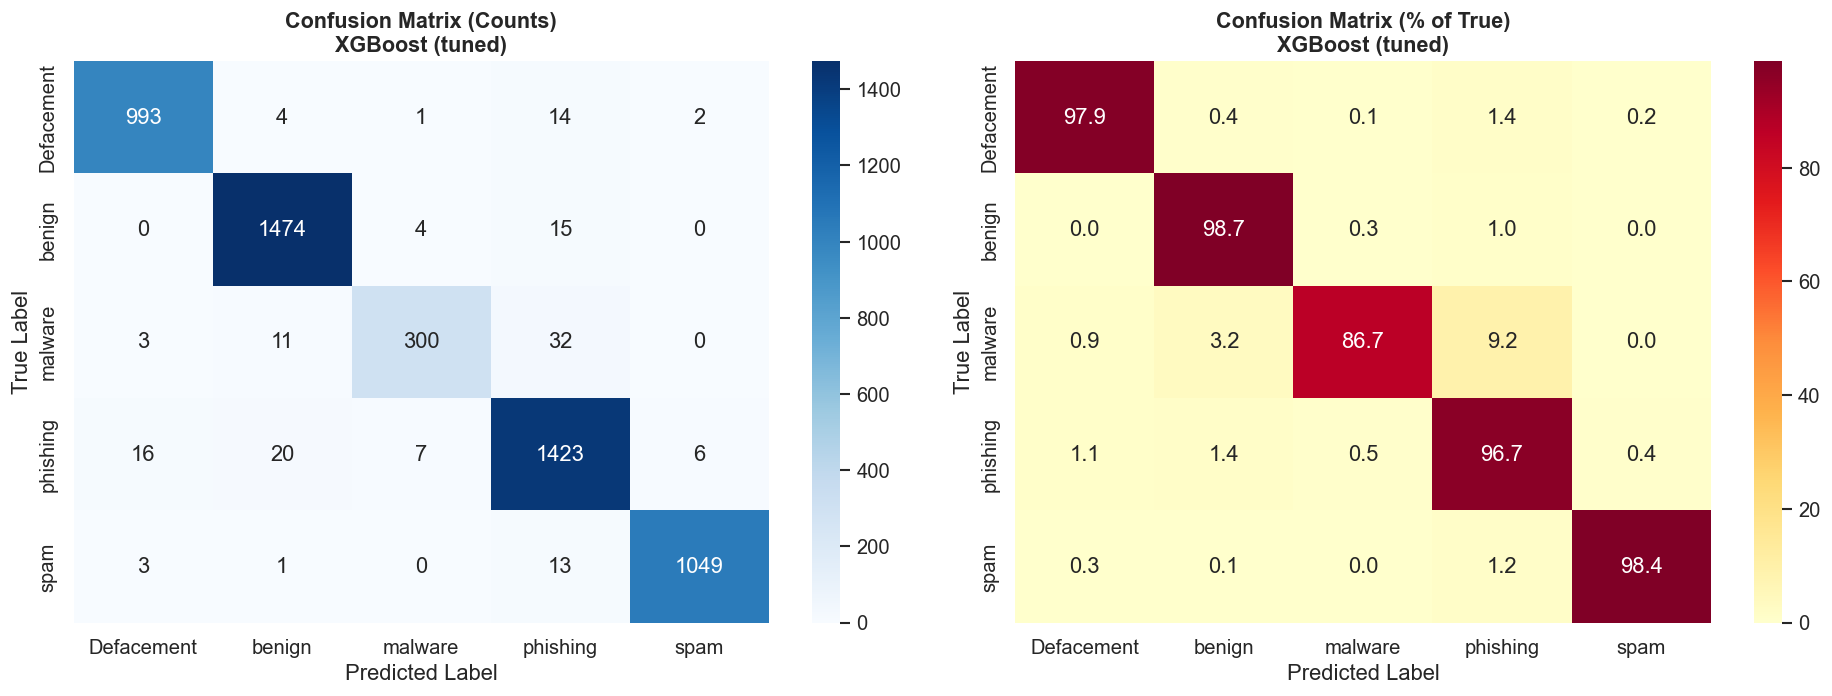

In [51]:
# ── 11.1 Confusion Matrix — Best Model ────────────────────────────────────────
y_pred_best = best_result['y_pred']
cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_key}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f'Confusion Matrix (% of True)\n{best_key}', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix_best.png', bbox_inches='tight')
plt.show()

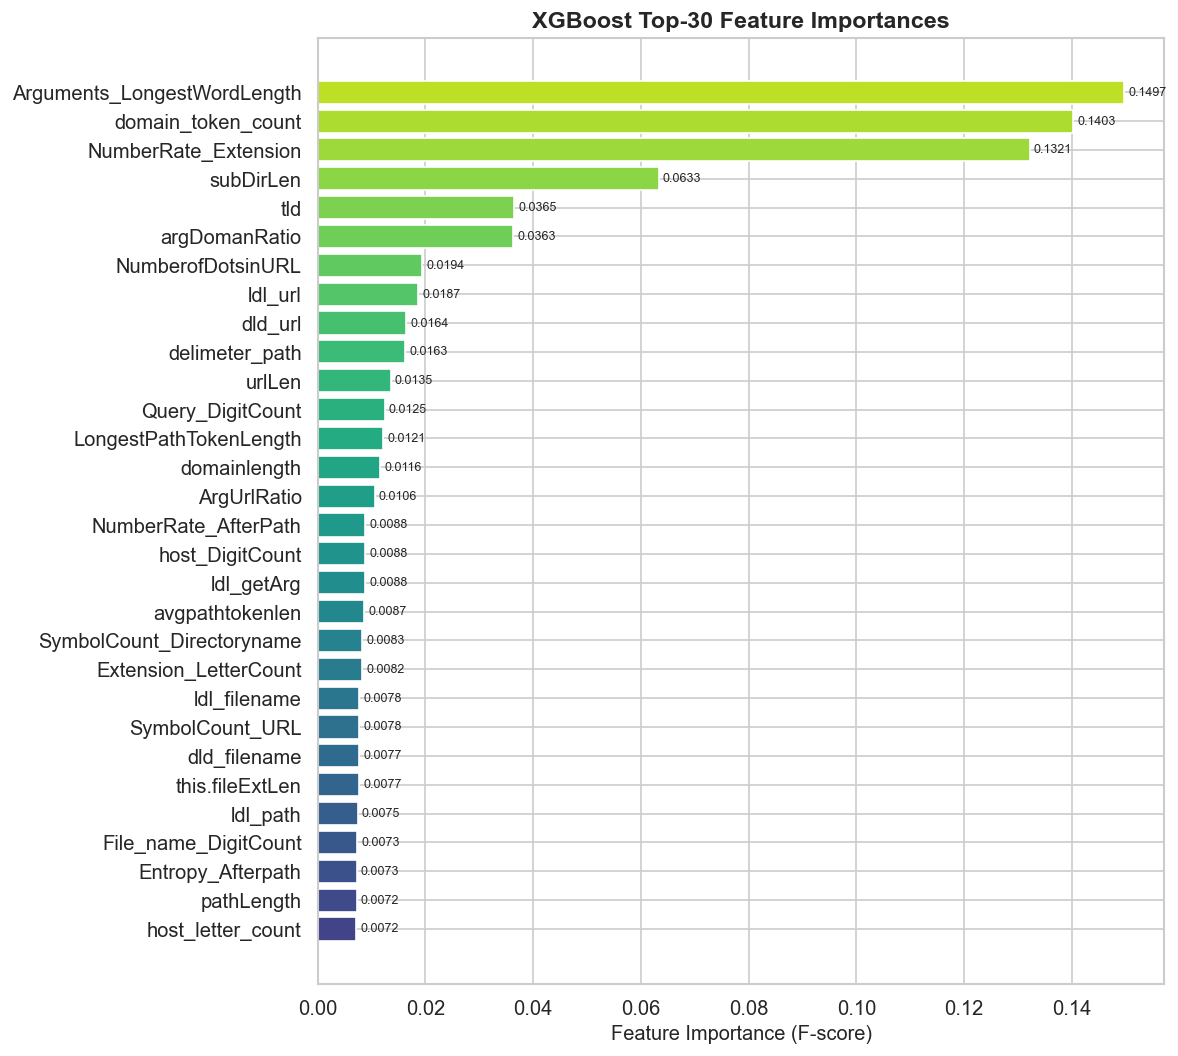

In [52]:
# ── 11.2 Feature Importance — XGBoost (top 30) ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, TOP_N))
bars = ax.barh(feat_imp.head(TOP_N).index[::-1],
               feat_imp.head(TOP_N).values[::-1],
               color=colors)
ax.set_xlabel('Feature Importance (F-score)', fontsize=12)
ax.set_title(f'XGBoost Top-{TOP_N} Feature Importances', fontsize=14, fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + feat_imp.max()*0.005,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=7.5)
plt.tight_layout()
plt.savefig('feature_importance_top30.png', bbox_inches='tight')
plt.show()

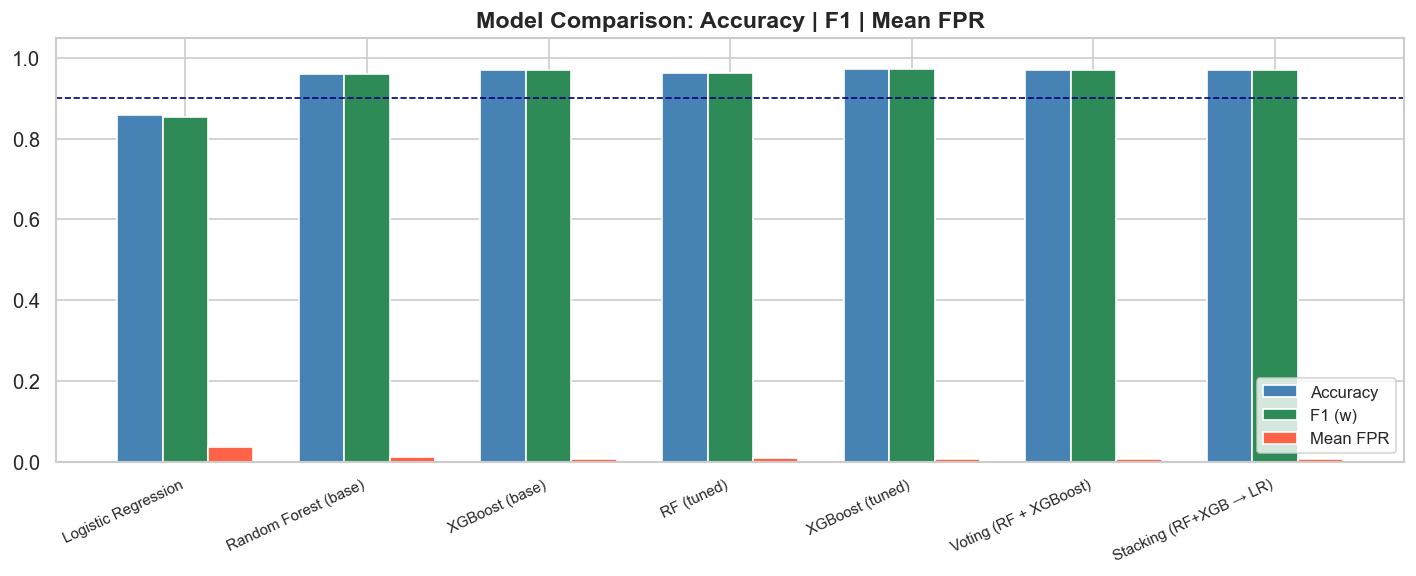

In [53]:
# ── 11.3 Model Comparison Chart ───────────────────────────────────────────────
# Focus on key comparable models
compare_keys = [
    'Logistic Regression', 'Random Forest (base)', 'XGBoost (base)',
    'RF (tuned)', 'XGBoost (tuned)', 'Voting (RF+XGB)', 'Stacking (RF+XGB→LR)'
]
compare_keys = [k for k in compare_keys if k in results]

comp_df = pd.DataFrame([
    {'Model': results[k]['model_name'],
     'Accuracy': results[k]['accuracy'],
     'F1 (w)': results[k]['f1'],
     'Mean FPR': results[k]['mean_fpr']}
    for k in compare_keys
])

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comp_df))
w = 0.25
ax.bar(x - w, comp_df['Accuracy'],  w, label='Accuracy',  color='steelblue')
ax.bar(x,     comp_df['F1 (w)'],    w, label='F1 (w)',     color='seagreen')
ax.bar(x + w, comp_df['Mean FPR'],  w, label='Mean FPR',   color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(comp_df['Model'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison: Accuracy | F1 | Mean FPR', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.90, color='navy', linestyle='--', linewidth=1, label='90% target')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

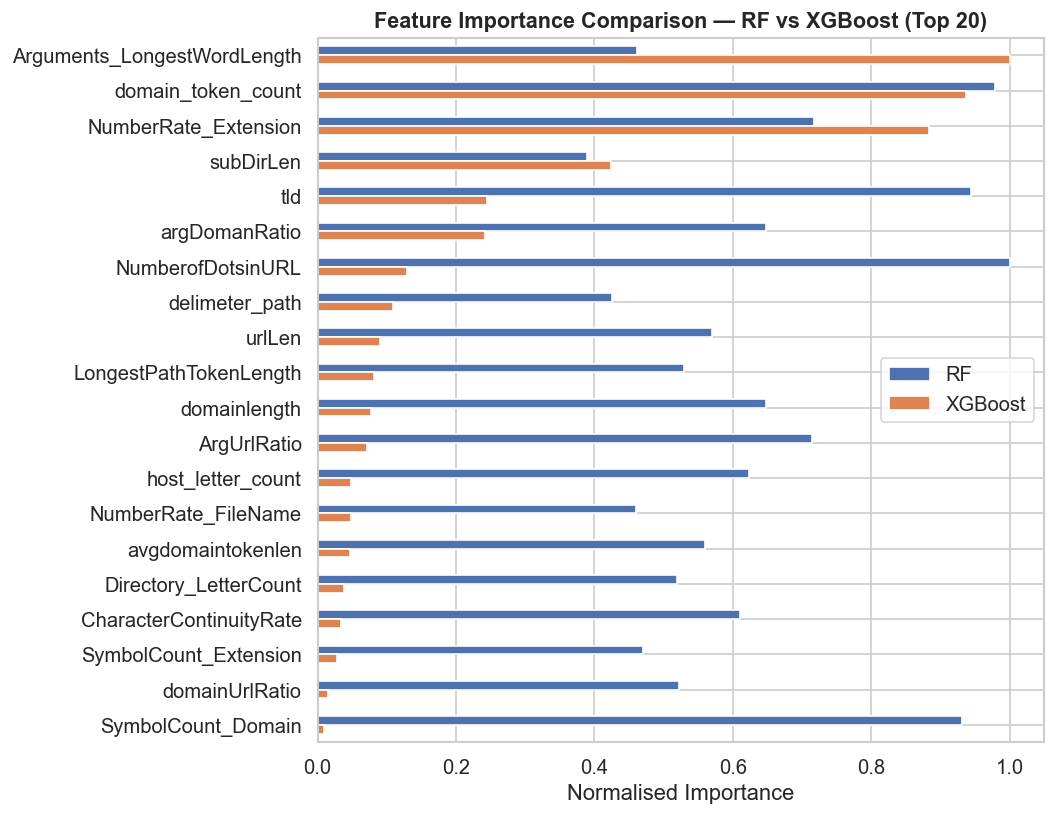

In [55]:
# ── 11.4 Feature Importance Comparison: RF vs XGBoost ─────────────────────────
rf_imp  = pd.Series(best_rf.feature_importances_, index=selected_features)
xgb_imp = pd.Series(best_xgb.feature_importances_, index=selected_features)

# Normalise to [0,1] for comparison
rf_imp_n  = rf_imp  / rf_imp.max()
xgb_imp_n = xgb_imp / xgb_imp.max()

TOP = 20
top_union = (rf_imp_n + xgb_imp_n).nlargest(TOP).index

comp_imp = pd.DataFrame({'RF': rf_imp_n[top_union], 'XGBoost': xgb_imp_n[top_union]})
comp_imp.sort_values('XGBoost', ascending=False, inplace=True)

comp_imp.plot(kind='barh', figsize=(9, 7), color=['#4C72B0', '#DD8452'])
plt.gca().invert_yaxis()
plt.title(f'Feature Importance Comparison — RF vs XGBoost (Top {TOP})', fontsize=13, fontweight='bold')
plt.xlabel('Normalised Importance')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', bbox_inches='tight')
plt.show()

---
## STEP 12 — Interpretation & Insights

In [57]:
print("="*65)
print("  FEATURE INTERPRETATION — Most Important Indicators")
print("="*65)

# Convert back to DataFrame
X_train_df = pd.DataFrame(X_train, columns=selected_features)
X_train_df['__label__'] = y_train

top10 = feat_imp.head(10)

for rank, (feat, score) in enumerate(top10.items(), 1):
    per_class = X_train_df.groupby('__label__')[feat].mean()
    per_class.index = le.classes_

    top_cls = per_class.idxmax()
    bot_cls = per_class.idxmin()

    print(f"\n  #{rank:02d} | {feat}  (importance: {score:.4f})")
    print(f"        Highest mean in : '{top_cls}' ({per_class[top_cls]:.4f})")
    print(f"        Lowest  mean in : '{bot_cls}' ({per_class[bot_cls]:.4f})")

print("\n" + "="*65)

  FEATURE INTERPRETATION — Most Important Indicators

  #01 | Arguments_LongestWordLength  (importance: 0.1497)
        Highest mean in : 'Defacement' (5.9556)
        Lowest  mean in : 'phishing' (-0.3985)

  #02 | domain_token_count  (importance: 0.1403)
        Highest mean in : 'spam' (3.3892)
        Lowest  mean in : 'benign' (2.0839)

  #03 | NumberRate_Extension  (importance: 0.1321)
        Highest mean in : 'spam' (0.2226)
        Lowest  mean in : 'benign' (-0.0899)

  #04 | subDirLen  (importance: 0.0633)
        Highest mean in : 'spam' (150.3838)
        Lowest  mean in : 'phishing' (45.1663)

  #05 | tld  (importance: 0.0365)
        Highest mean in : 'spam' (3.3892)
        Lowest  mean in : 'benign' (2.0839)

  #06 | argDomanRatio  (importance: 0.0363)
        Highest mean in : 'spam' (7.4970)
        Lowest  mean in : 'phishing' (0.6194)

  #07 | NumberofDotsinURL  (importance: 0.0194)
        Highest mean in : 'spam' (3.6748)
        Lowest  mean in : 'benign' (1.714

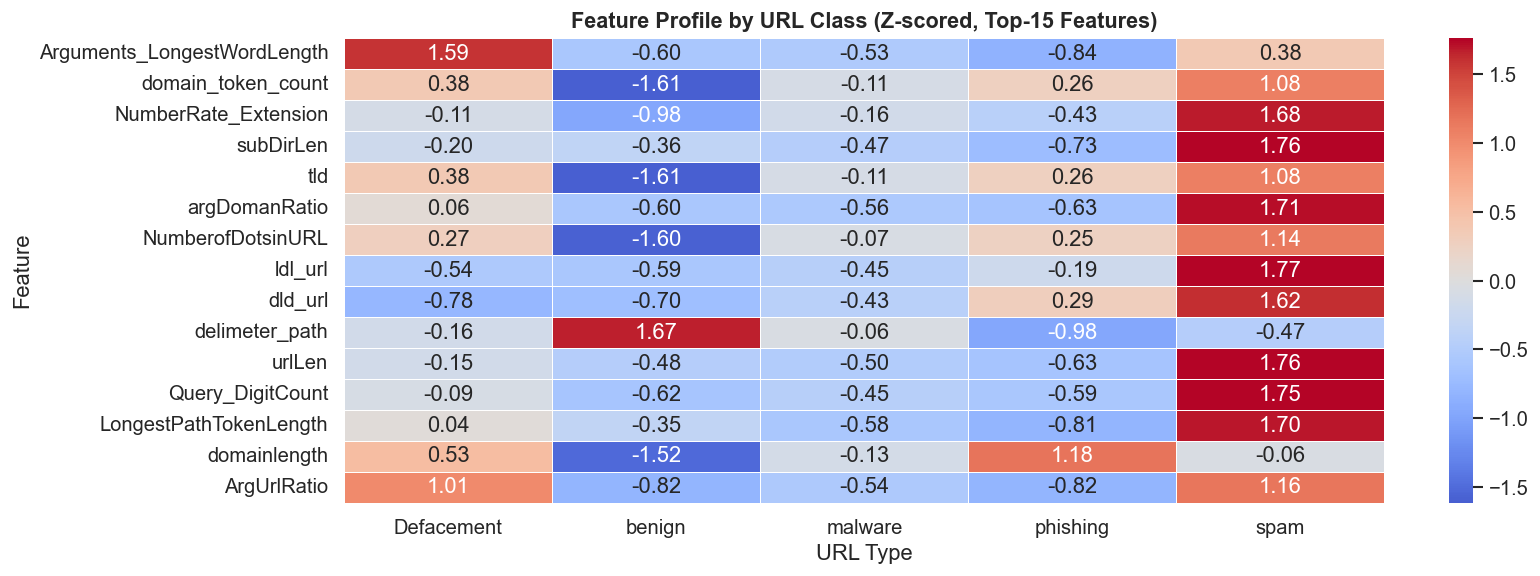

In [59]:
# ── 12.2 Per-class feature heatmap (top 15 features × all classes) ─────────────
top15_feats = feat_imp.head(15).index.tolist()

# Convert to DataFrame
X_train_df = pd.DataFrame(X_train, columns=selected_features)
X_train_df['__label__'] = y_train

# Group by class
profile_df = X_train_df.groupby('__label__')[top15_feats].mean()
profile_df.index = le.classes_

# Z-score normalize
profile_z = (profile_df - profile_df.mean()) / (profile_df.std() + 1e-9)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    profile_z.T, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.4, ax=ax
)

ax.set_title('Feature Profile by URL Class (Z-scored, Top-15 Features)', fontsize=13, fontweight='bold')
ax.set_xlabel('URL Type')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('feature_profile_heatmap.png', bbox_inches='tight')
plt.show()

In [60]:
# ── 12.3 Final Summary Report ─────────────────────────────────────────────────
print("\n" + "="*65)
print("  FINAL PIPELINE SUMMARY")
print("="*65)
print(f"  Dataset        : {df.shape[0]:,} samples × {X.shape[1]} features")
print(f"  Classes        : {list(le.classes_)}")
print(f"  Train / Test   : {len(X_train):,} / {len(X_test):,}")
print(f"  Selected feats : {best_n} (top-{best_n} by XGBoost importance)")
print("")
print(f"  Best Model     : {best_row['Model']}")
print(f"  Accuracy       : {best_row['Accuracy']:.4f}")
print(f"  F1 (weighted)  : {best_row['F1 (w)']}")
print(f"  ROC-AUC        : {best_row['ROC-AUC']}")
print(f"  Mean FPR       : {best_row['Mean FPR']}")
print("")

acc_val = float(best_row['Accuracy'])
fpr_val = float(best_row['Mean FPR'])

print("  Performance Goals:")
print(f"  Accuracy ≥ 90%   : {'✅ ACHIEVED' if acc_val >= 0.90 else '❌ NOT MET'} ({acc_val*100:.2f}%)")
print(f"  Mean FPR ≤ 5%    : {'✅ ACHIEVED' if fpr_val <= 0.05 else '⚠️  CHECK'} ({fpr_val*100:.2f}%)")
print("="*65)


  FINAL PIPELINE SUMMARY
  Dataset        : 26,953 samples × 72 features
  Classes        : ['Defacement', 'benign', 'malware', 'phishing', 'spam']
  Train / Test   : 21,562 / 5,391
  Selected feats : 40 (top-40 by XGBoost importance)

  Best Model     : XGBoost (tuned)
  Accuracy       : 0.9718
  F1 (weighted)  : 0.9716
  ROC-AUC        : 0.9983
  Mean FPR       : 0.0075

  Performance Goals:
  Accuracy ≥ 90%   : ✅ ACHIEVED (97.18%)
  Mean FPR ≤ 5%    : ✅ ACHIEVED (0.75%)


In [61]:
# ── 12.4 Save best model ───────────────────────────────────────────────────────
import joblib

best_model_obj = best_result['model']
joblib.dump(best_model_obj, 'best_url_classifier.pkl')
joblib.dump(le,             'label_encoder.pkl')
joblib.dump(scaler,         'scaler.pkl')

print("✅ Artefacts saved:")
print("   • best_url_classifier.pkl")
print("   • label_encoder.pkl")
print("   • scaler.pkl")
print("\n  To load and predict:")
print("    import joblib")
print("    model = joblib.load('best_url_classifier.pkl')")
print("    le    = joblib.load('label_encoder.pkl')")
print("    preds = le.inverse_transform(model.predict(X_new))")

✅ Artefacts saved:
   • best_url_classifier.pkl
   • label_encoder.pkl
   • scaler.pkl

  To load and predict:
    import joblib
    model = joblib.load('best_url_classifier.pkl')
    le    = joblib.load('label_encoder.pkl')
    preds = le.inverse_transform(model.predict(X_new))
